

```
# author: puru panta (purupanta@uky.edu)
# date: 11/30/2024
# filename: PredictMLDL_Stacked
```



**STEP1: Install and Import libraries required**

In [1]:
import json

# Mounting google drive if it is already not mounted
def LoadGoogleDrive(googleDriveDir):
  # Link Google Drive
  import os
  # Check if Google Drive is already mounted
  if not os.path.exists(googleDriveDir + "/MyDrive"):
      print("Mounting Google Drive...")
      from google.colab import drive
      drive.mount(googleDriveDir)
  else:
      print("Google Drive is already mounted!")

# Loading the AppConfig file
def LoadAppConfig(json_file_path):
  # Load JSON file into a Python dictionary
  with open(json_file_path, "r") as json_file:
      config_data = json.load(json_file)

  # Print loaded JSON data
  print("AppConfig JSON File Loaded Successfully!")
  # print(config_data)
  return config_data

# Loading the AppLib file
def AppLib_reload_script(script_path):
  # Load AppLib.py
  with open(script_path, 'r') as file:
      script_code = file.read()
      exec(script_code, globals())

# Pick the balance sample of Heart Condition 0 and 1
def PickBalanceSample(X_unbal, y_unbal):

  # Combine features and labels for easy manipulation
  data = pd.concat([X_unbal, y_unbal], axis=1)

  # Separate the two classes
  class_0 = data[data[y_unbal.name] == 0]
  class_1 = data[data[y_unbal.name] == 1]

  # Determine the minimum class size
  min_class_count = min(len(class_0), len(class_1))

  # Sample equal number from both classes
  class_0_bal = class_0.sample(min_class_count, random_state=42)
  class_1_bal = class_1.sample(min_class_count, random_state=42)

  # Combine and shuffle
  balanced_data = pd.concat([class_0_bal, class_1_bal]).sample(frac=1, random_state=42)

  # Split features and labels again
  X_bal = balanced_data.drop(y.name, axis=1)
  y_bal = balanced_data[y.name]

  return X_bal, y_bal

# Standard Scaler
def StandardScale_Data(X_train, X_test):
  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
  X_test_scaled = scaler.transform(X_test)         # transform test data
  return X_train_scaled, X_test_scaled

# SMOTEENN
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

def Tuned_Smoteenn_Data(X_train, y_train):
  smote = SMOTE(sampling_strategy=0.8, k_neighbors=3, random_state=42)
  enn = EditedNearestNeighbours(n_neighbors=3)
  smote_enn = SMOTEENN(smote=smote, enn=enn)
  X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

  from collections import Counter
  # Check class distribution after resampling
  print("Before SMOTEENN:", Counter(y_train))
  print("After SMOTEENN:", Counter(y_train_res))
  return X_train_res, y_train_res

**STEP2: Load google-drive, libraries, config file and application library file**

In [2]:
# Mount the google drive
googleDriveFolder = "/content/drive"
LoadGoogleDrive(googleDriveFolder)

# Load the AppConfig json file
json_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/AppConfig.json"
config_data = LoadAppConfig(json_file_path)

# Load AppLib
lib_script_path = config_data["project_location"] + config_data["app_lib_path"] + config_data["app_lib_filename"]
print(f"Loading AppLib from: {lib_script_path}")
AppLib_reload_script(lib_script_path)

# Load the libraries
requirements_path = config_data["project_location"] + config_data["requirements_file_name"]
AppLib.LoadRequirements(requirements_path)


Mounting Google Drive...
Mounted at /content/drive
AppConfig JSON File Loaded Successfully!
Loading AppLib from: drive/MyDrive/Colab Notebooks/P_HINTS6/lib/AppLib.py
Installing missing packages: ['tf-keras', 'scikit-learn', 'imbalanced-learn', 'xlsxwriter']
Installation completed successfully!
Please restart the runtime for changes to take effect.


**STEP3: Load the original data with filtered columns**

In [13]:
# Define the output file path
ip_file_path = config_data["project_location"] + config_data["op_data_dir"] + config_data["op_file_name_cleaned"];
ip_sheet_name = config_data["op_file_sheet_name_cleaned"]
ip_load_data_cols = config_data["study_cols"]["target_cols"] + config_data["study_cols"]["predictor_cols"] + config_data["study_cols"]["predictor_cols0"]
# Loading cleaded excel data
df_rowColFilteredCleaned = AppLib.load_data(ip_file_path, ip_sheet_name, ip_load_data_cols)

# Copy of it to further use
df = df_rowColFilteredCleaned.copy()

Data Size: 87750, Data Shape: (4875, 18), (Flag: Loaded, original data)


**STEP4: Define target and predictors**

In [14]:
predictors = config_data["study_cols"]["predictor_cols"] + config_data["study_cols"]["predictor_cols0"]
target = config_data["study_cols"]["target_cols"]
X, y = AppLib.define_target_predictors(df, predictors, target)

Unique values in the target variable after filtering: [1 0]


In [18]:
X_bal, y_bal = PickBalanceSample(X, y)
print(f"Before balancing: X = {X.shape}, y = {y.shape} ")
print(f"After balancing: X_bal = {X_bal.shape}, y_bal = {y_bal.shape} ")

Before balancing: X = (4875, 17), y = (4875,) 
After balancing: X_bal = (912, 17), y_bal = (912,) 


**STEP7: Train-Test Split**

In [19]:
# 1. Train-test split

# X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, stratify=y_bal, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Reshape the target variable if necessary
y_train = y_train.to_numpy().ravel()  # Convert to 1D array
y_test = y_test.to_numpy().ravel()    # Convert to 1D array


In [21]:
# 2. Apply SMOTEENN on the training data

# Use this function:
X_train_res, y_train_res = Tuned_Smoteenn_Data(X_train, y_train)

# 3. Standard scale the data
X_train_res_scaled, X_test_res_scaled = StandardScale_Data(X_train_res, X_test)


Before SMOTEENN: Counter({np.int64(0): 3535, np.int64(1): 365})
After SMOTEENN: Counter({np.int64(1): 2828, np.int64(0): 2364})


In [22]:
# Train/Test assignments
X_train_dyn_stacked = X_train_res_scaled.copy()
y_train_dyn_stacked = y_train_res.copy()
X_test_dyn_stacked = X_test_res_scaled.copy()
y_test_dyn_stacked = y_test.copy()

In [23]:
# import pandas as pd
# print(len(X_train_dyn_stacked))
# Convert to DataFrame, then sample
# df = pd.DataFrame(X_train_dyn_stacked)
# print(df.sample(5))

# print(len(y_train_dyn_stacked))
# pd.Series(y_train_dyn_stacked).sample(5)

**STEP8: Prediction Starts**

In [24]:
import pandas as pd
import numpy as np
import time
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from collections import defaultdict

!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn

**1. Stacked Model with dynamic routing**

In [25]:
# STEP 1: Define Base Models
base_models = {
    'rf': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'lr': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    'svm': SVC(kernel='poly', probability=True, class_weight='balanced', random_state=42),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'gbm': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}


In [26]:
def generate_oof_meta_features(X, y, base_models_dict, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    num_models = len(base_models_dict)
    meta_features = np.zeros((X.shape[0], num_models * 3 + 1))  # prob + class + confidence + agreement
    best_model_labels = np.zeros(X.shape[0], dtype=int)

    for train_idx, val_idx in skf.split(X, y):
        fold_models = {name: clone(model) for name, model in base_models_dict.items()}
        f1_scores = np.zeros((len(val_idx), num_models))
        preds_matrix = np.zeros((len(val_idx), num_models))
        probs_matrix = np.zeros((len(val_idx), num_models))
        confidences_matrix = np.zeros((len(val_idx), num_models))

        for j, (name, model) in enumerate(fold_models.items()):
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            probs = model.predict_proba(X[val_idx])[:, 1]

            preds_matrix[:, j] = preds
            probs_matrix[:, j] = probs
            confidences_matrix[:, j] = np.abs(probs - 0.5)  # confidence

            f1 = f1_score(y[val_idx], preds, pos_label=1)
            f1_scores[:, j] = f1

        # Compute meta features
        for i, idx in enumerate(val_idx):
            meta_row = []
            # 1. Probabilities
            meta_row.extend(probs_matrix[i])
            # 2. Predicted classes
            meta_row.extend(preds_matrix[i])
            # 3. Confidences
            meta_row.extend(confidences_matrix[i])
            # 4. Agreement count (how many base models agree on same class)
            majority_vote = np.bincount(preds_matrix[i].astype(int)).argmax()
            agreement_count = np.sum(preds_matrix[i] == majority_vote)
            meta_row.append(agreement_count)
            meta_features[idx] = meta_row

        # Use model with highest F1-score on class 1 for routing label
        best_model_labels[val_idx] = np.argmax(f1_scores, axis=1)

    return meta_features, best_model_labels


In [27]:
##### STEP1: Generate router training data using OOF: Predicted probabilities and Best model

meta_X_router, best_model_labels = generate_oof_meta_features(X_train_dyn_stacked, y_train_dyn_stacked, base_models)

print("Meta-features shape:", meta_X_router.shape)
print("Best model labels shape:", best_model_labels.shape)

# Train final base models on full training set
trained_base_models = {name: model.fit(X_train_dyn_stacked, y_train_dyn_stacked) for name, model in base_models.items()}

# Train router
router = RandomForestClassifier(n_estimators=100, class_weight='balanced',  random_state=42)
router.fit(meta_X_router, best_model_labels)

Meta-features shape: (5192, 16)
Best model labels shape: (5192,)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [28]:
##### STEP2:

# Prepare test meta-features
# meta_X_test_router = np.column_stack([
    # model.predict_proba(X_test_dyn_stacked)[:, 1] for model in trained_base_models.# values()
# ])

# Generate meta-features for the test set (to match training features)
test_probs = []
test_preds = []
test_confidences = []

for model in trained_base_models.values():
    probs = model.predict_proba(X_test_dyn_stacked)[:, 1]
    preds = model.predict(X_test_dyn_stacked)
    conf = np.abs(probs - 0.5)

    test_probs.append(probs)
    test_preds.append(preds)
    test_confidences.append(conf)

# Convert to arrays for stacking
test_probs = np.column_stack(test_probs)              # shape: (n_samples, 5)
test_preds = np.column_stack(test_preds)              # shape: (n_samples, 5)
test_confidences = np.column_stack(test_confidences)  # shape: (n_samples, 5)

# Agreement count per sample
from scipy.stats import mode
majority_votes, _ = mode(test_preds, axis=1, keepdims=True)
agreement_counts = np.sum(test_preds == majority_votes, axis=1).reshape(-1, 1)  # shape: (n_samples, 1)

# Concatenate all test meta-features
meta_X_test_router = np.hstack([
    test_probs, test_preds, test_confidences, agreement_counts
])  # Final shape: (n_samples, 16)


Dynamic Routing Accuracy: 0.79
Dynamic Routing AUC-ROC: 0.71
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       884
           1       0.21      0.45      0.28        91

    accuracy                           0.79       975
   macro avg       0.57      0.64      0.58       975
weighted avg       0.87      0.79      0.82       975



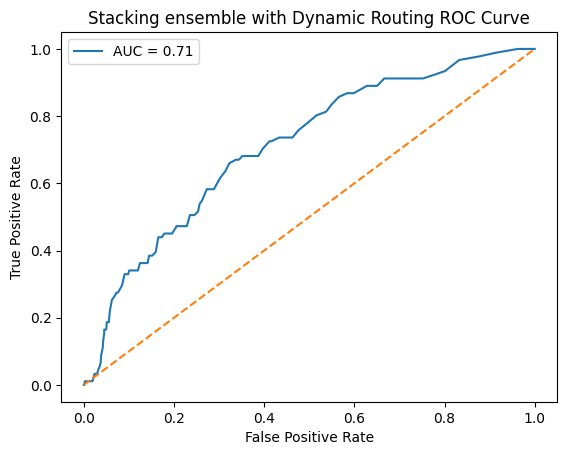

Total execution time: 0.17 seconds


In [29]:
# Get router’s selected model for each sample
selected_model_indices = router.predict(meta_X_test_router)
model_names = list(trained_base_models.keys())


from collections import defaultdict

# Start timing
start_time = time.time()

# Group test sample indices by the model selected by the router
grouped_indices = defaultdict(list)
for i, model_idx in enumerate(selected_model_indices):
    grouped_indices[model_idx].append(i)

# Prepare arrays to hold final predictions and probabilities
final_preds = np.zeros(len(X_test_dyn_stacked), dtype=int)
final_probs = np.zeros(len(X_test_dyn_stacked))

# Predict in batches for each model group
for model_idx, indices in grouped_indices.items():
    model = trained_base_models[model_names[model_idx]]
    X_batch = X_test_dyn_stacked[indices]
    final_preds[indices] = model.predict(X_batch)
    final_probs[indices] = model.predict_proba(X_batch)[:, 1]


#####STEP3:
accuracy = accuracy_score(y_test_dyn_stacked, final_preds)
roc_auc = roc_auc_score(y_test_dyn_stacked, final_probs)
print(f"Dynamic Routing Accuracy: {accuracy:.2f}")
print(f"Dynamic Routing AUC-ROC: {roc_auc:.2f}")
print(classification_report(y_test_dyn_stacked, final_preds))

# Plot ROC
fpr, tpr, _ = roc_curve(y_test_dyn_stacked, final_probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacking ensemble with Dynamic Routing ROC Curve')
plt.legend()
plt.show()

# Stop timing
end_time = time.time()

# Calculate execution time
execution_time = end_time - start_time
print(f"Total execution time: {execution_time:.2f} seconds")